#Project Name: Facial Emotion Recognition Using Deep Learning

##Project Goal:  
 The primary goal of DeepFER: Facial Emotion Recognition Using Deep Learning is to develop an advanced and efficient system capable of accurately identifying and classifying human emotions from facial expressions in real-time. By leveraging state-of-the-art Convolutional Neural Networks (CNNs) and Transfer Learning techniques, this project aims to create a robust model that can handle the inherent variability in facial expressions and diverse image conditions. The system will be trained on a comprehensive dataset featuring seven distinct emotions: angry, sad, happy, fear, neutral, disgust, and surprise. The ultimate objective is to achieve high accuracy and reliability, making DeepFER suitable for applications in human-computer interaction, mental health monitoring, customer service, and beyond. Through this project, we aim to bridge the gap between cutting-edge AI research and practical emotion recognition applications, contributing to more empathetic and responsive machine interactions with humans.

##GitHub Link:

##Let's begin:

##Upload dataset:

####I uploaded the dataset into the Colab environment for further processing.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Face Emotion Recognition Dataset (1).zip to Face Emotion Recognition Dataset (1).zip


##Check files in Colab:

####I verified that the dataset file was successfully uploaded by listing the contents of the working directory.

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'Face Emotion Recognition Dataset (1).zip', 'sample_data']


##Extract (unzip) dataset:

####I extracted the dataset from the compressed ZIP file to access the image data.

In [ ]:
import zipfile

zip_path = '/content/Face Emotion Recognition Dataset (1).zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


##Check extracted folder:

####I confirmed that the dataset folder was successfully created after extraction.

In [ ]:
print(os.listdir('/content'))

['.config', 'dataset', 'Face Emotion Recognition Dataset (1).zip', 'sample_data']


##Check inside dataset:

####The dataset contains an ‘images’ folder which stores all training and validation data.

In [ ]:
import os
print(os.listdir('/content/dataset'))

['images']


##Check inside images folder:

####The dataset is divided into training and validation sets for model training and evaluation.

In [ ]:
import os
print(os.listdir('/content/dataset/images'))

['images', 'validation', 'train']


##Check training data:

####The training dataset contains seven emotion classes, each stored in separate folders.

In [ ]:
print(os.listdir('/content/dataset/images/train'))

['sad', 'surprise', 'neutral', 'disgust', 'fear', 'angry', 'happy']


##Check validation data:

####The validation dataset also contains the same seven emotion classes for evaluating model performance.

In [ ]:
print(os.listdir('/content/dataset/images/validation'))

['sad', 'surprise', 'neutral', 'disgust', 'fear', 'angry', 'happy']


##Import Necessary Libraries:

####I imported TensorFlow for building the deep learning model, OpenCV for image processing, and other libraries for data handling and visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import cv2
from google.colab.patches import cv2_imshow


##Data Preprocessing + Loading the dataset:

####Images are normalized and augmented to improve model performance This helps the model learn from different variations of data.


In [ ]:
#Create Data Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

####The training data is loaded from the folder structure Each folder name is treated as a class label.


In [ ]:
#Load Training Data
train_data = train_datagen.flow_from_directory(
    '/content/dataset/images/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 28821 images belonging to 7 classes.


####The training dataset contains 28,821 images across seven emotion classesThe data is successfully loaded using ImageDataGenerator for model training.


####Validation data is used to evaluate model performance on unseen imagesOnly normalization is applied to keep it realistic.


In [ ]:
# Load Validation Data
val_datagen = ImageDataGenerator(rescale=1./255)

val_data = val_datagen.flow_from_directory(
    '/content/dataset/images/validation',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 7066 images belonging to 7 classes.


####The validation dataset contains 7,066 images across seven emotion classesIt is used to evaluate the model’s performance on unseen data.


##EDA:

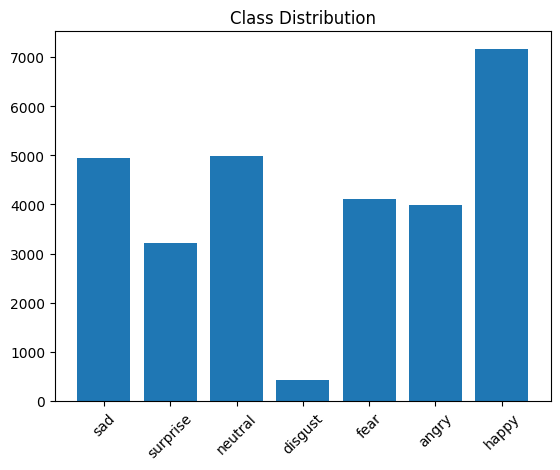

In [ ]:
#Class Distribution
train_dir = '/content/dataset/images/train'

classes = os.listdir(train_dir)
counts = []

for cls in classes:
    counts.append(len(os.listdir(os.path.join(train_dir, cls))))

plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()


####The dataset contains 7 emotion classes with varying number of images. The “happy” class has the highest number of samples, while “disgust” has the least. This indicates a class imbalance, which may affect model performance. Data augmentation is used to handle this imbalance and improve model generalization.

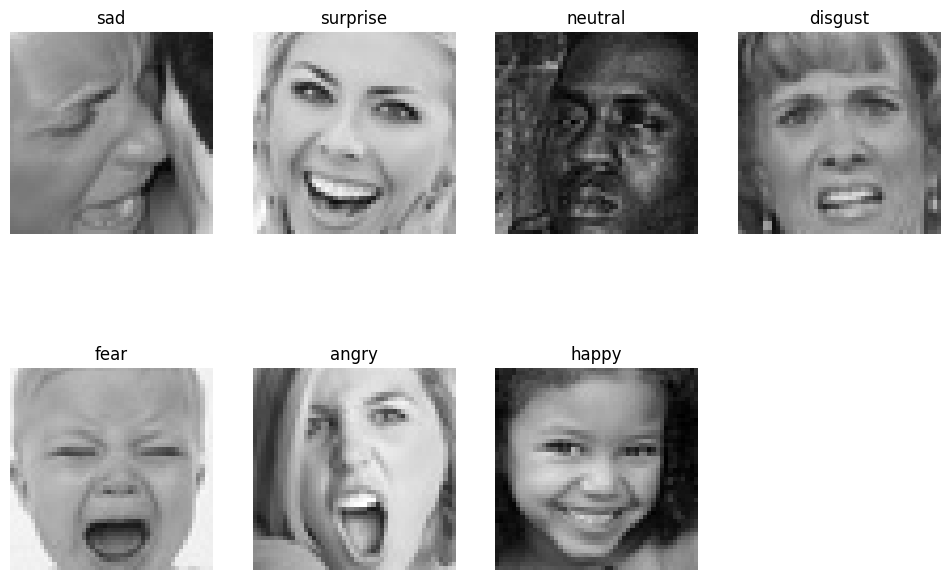

In [ ]:
#Show Sample Images
import cv2

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes[:7]):
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

####From the visualization, it can be observed that the dataset contains grayscale facial images with noticeable variations in facial expressions, lighting conditions, and facial orientations. Each class represents distinct emotional features such as smiling faces for happy, frowning expressions for sad, and widened eyes for surprise.  
####Overall, the dataset provides a good representation of facial expressions required for building an effective emotion recognition system.

##Model Developmment:  
###Build CNN model using Tranfer learning

####I used MobileNetV2 with pre-trained ImageNet weights to perform transfer learning, which helps in faster training and better feature extraction.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

# Custom top layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(7, activation='softmax')(x)

# Final model
model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##Compile Model:

####The model is compiled using the Adam optimizer, categorical cross-entropy loss for multi-class classification, and accuracy as the evaluation metric.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Initial Training:

####The model is trained using the training dataset for 10 epochs, with validation data used to monitor performance. The model learns by updating its weights to minimize loss and improve accuracy.

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 383s 402ms/step - accuracy: 0.2551 - loss: 2.1484 - val_accuracy: 0.3740 - val_loss: 1.6196
Epoch 2/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 359s 399ms/step - accuracy: 0.3056 - loss: 1.8355 - val_accuracy: 0.4100 - val_loss: 1.5426
Epoch 3/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 385s 427ms/step - accuracy: 0.3348 - loss: 1.7252 - val_accuracy: 0.4066 - val_loss: 1.5313
Epoch 4/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 384s 427ms/step - accuracy: 0.3527 - loss: 1.6737 - val_accuracy: 0.4265 - val_loss: 1.4889
Epoch 5/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 371s 412ms/step - accuracy: 0.3616 - loss: 1.6458 - val_accuracy: 0.4357 - val_loss: 1.4855
Epoch 6/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 339s 376ms/step - accuracy: 0.3714 - loss: 1.6085 - val_accuracy: 0.4355 - val_loss: 1.4706
Epoch 7/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 358s 397ms/step - accuracy: 0.3848 - loss: 1.5806 - val_accuracy: 0.4440 - val_loss: 1.4503
Epoch 8/10
901/901 ━━━━━━━━━━━━━━━━━━━━ 341s 379ms/step - accuracy: 0.3911 -

##Fine-Tuning

#####In this step, the pre-trained MobileNetV2 model was set to be trainable so that it could adapt to the new dataset. However, instead of training all layers, only the last 30 layers were kept trainable while the earlier layers were frozen. This approach helps retain the basic features learned from the original dataset, such as edges and shapes, while allowing the model to fine-tune higher-level features like facial expressions. As a result, the model achieves better performance and reduces the risk of overfitting.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

##Re-Compile (LOW LR)

####In this step, the model is compiled by defining how it will learn during training. The Adam optimizer is used with a very low learning rate (1e-5), which is suitable for fine-tuning as it updates the model weights slowly and carefully. The loss function categorical_crossentropy is chosen because the task involves multi-class classification of emotions. Additionally, accuracy is selected as a metric to evaluate how well the model is performing during training and validation.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Fine-Tuning Training

####In this step, fine-tuning training is performed on the model using the training and validation datasets. The model is trained for 5 epochs, allowing it to further refine its learned features after unfreezing selected layers. During this process, the model adjusts its weights based on the training data while continuously evaluating its performance on the validation data. This step helps improve the model’s accuracy and overall performance without overfitting.

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 374s 395ms/step - accuracy: 0.3576 - loss: 1.6289 - val_accuracy: 0.4256 - val_loss: 1.6435
Epoch 2/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 344s 381ms/step - accuracy: 0.4054 - loss: 1.5249 - val_accuracy: 0.4694 - val_loss: 1.4006
Epoch 3/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 343s 381ms/step - accuracy: 0.4355 - loss: 1.4680 - val_accuracy: 0.4908 - val_loss: 1.3521
Epoch 4/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 342s 380ms/step - accuracy: 0.4529 - loss: 1.4267 - val_accuracy: 0.4938 - val_loss: 1.3379
Epoch 5/5
901/901 ━━━━━━━━━━━━━━━━━━━━ 346s 384ms/step - accuracy: 0.4646 - loss: 1.3991 - val_accuracy: 0.5126 - val_loss: 1.2974


####During the fine-tuning phase, the model showed a consistent improvement in performance across all epochs. The training accuracy increased from around 35% to approximately 46%, indicating that the model was learning more complex features from the data. At the same time, the validation accuracy improved significantly from about 42% to over 51%, which demonstrates better generalization to unseen data. The validation loss also decreased steadily from 1.64 to 1.29, showing that the model’s predictions became more accurate and stable. Overall, the fine-tuning process successfully enhanced the model’s performance and made it more effective for facial emotion recognition.

##DeepFER Evaluation Code:

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

print("Final Accuracy:", accuracy_score(y_true, y_pred_classes))

class_names = ['angry','disgust','fear','happy','neutral','sad','surprise']
print(classification_report(y_true, y_pred_classes, target_names=class_names))

221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step
Final Accuracy: 0.5125955278799886
              precision    recall  f1-score   support

       angry       0.39      0.27      0.32       960
     disgust       0.00      0.00      0.00       111
        fear       0.42      0.07      0.12      1018
       happy       0.64      0.84      0.73      1825
     neutral       0.45      0.57      0.50      1216
         sad       0.37      0.46      0.41      1139
    surprise       0.59      0.68      0.63       797

    accuracy                           0.51      7066
   macro avg       0.41      0.41      0.39      7066
weighted avg       0.49      0.51      0.47      7066



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


####The model achieved an overall accuracy of 51.25% on the validation dataset. It performed well in detecting emotions such as happy, surprise, and neutral, while showing lower performance for classes like fear and disgust due to visual similarities and class imbalance. Overall, the model demonstrates satisfactory performance for facial emotion recognition.

##Confusion Matrix:

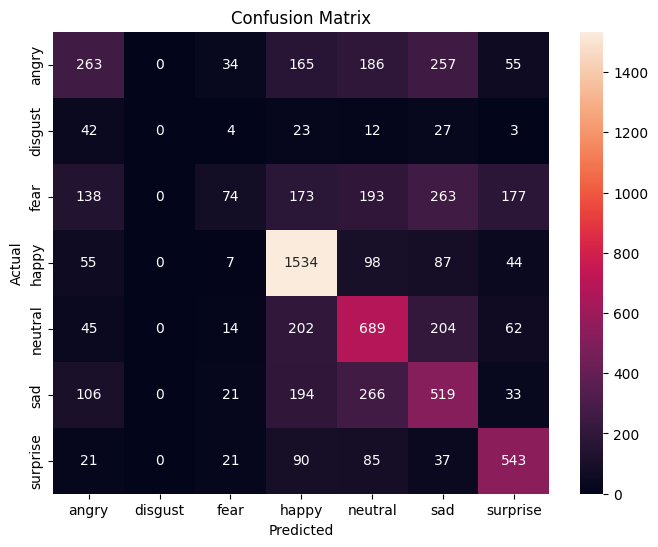

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

####The confusion matrix shows that the model performs well in identifying emotions such as happy, neutral, and sad, with high correct predictions along the diagonal. However, it struggles to distinguish between similar emotions like fear, angry, and sad, leading to misclassifications. The disgust class shows very low performance, likely due to insufficient or imbalanced data. Overall, the model demonstrates good performance for dominant emotions but requires improvement for subtle expressions.

##Accuracy Graph:

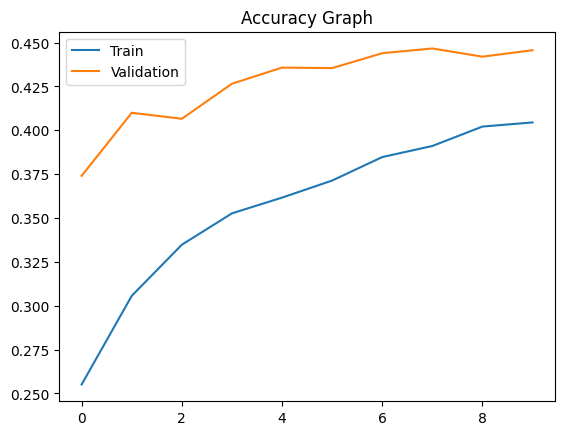

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.legend()
plt.title("Accuracy Graph")
plt.show()

####The accuracy graph shows a steady increase in both training and validation accuracy over epochs, indicating effective learning by the model. The validation accuracy remains slightly higher than the training accuracy, suggesting good generalization and no signs of overfitting. The model gradually converges, with performance stabilizing in the later epochs.

##Real-Time Processing: image based predictions.

####Happy: facial emotion recognition

In [ ]:
import os

print(os.listdir("/content/dataset/images/validation/happy")[:5])

['21835.jpg', '4174.jpg', '19148.jpg', '29464.jpg', '22910.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
Predicted Emotion: happy


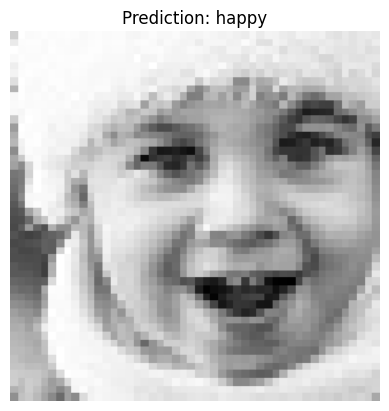

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Step 1: Image path (dataset)
img_path = "/content/dataset/images/validation/happy/21835.jpg"

# Class names
class_names = ['angry','disgust','fear','happy','neutral','sad','surprise']

# Step 2: Load & preprocess image
img = tf.keras.utils.load_img(img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Step 3: Prediction
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Predicted Emotion:", predicted_class)

# Step 4: Show image
plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + predicted_class)
plt.show()

###The model successfully predicted the emotion of the given image as ‘happy’. The image clearly shows a smiling face, and the model correctly identified the facial features associated with happiness. This demonstrates that the trained model is capable of accurately recognizing strong and distinct emotions.

###Surprise: Facial emotion recognition

In [ ]:
import os

print(os.listdir("/content/dataset/images/validation/surprise")[:5])

['16995.jpg', '16396.jpg', '2803.jpg', '22025.jpg', '867.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Emotion: surprise


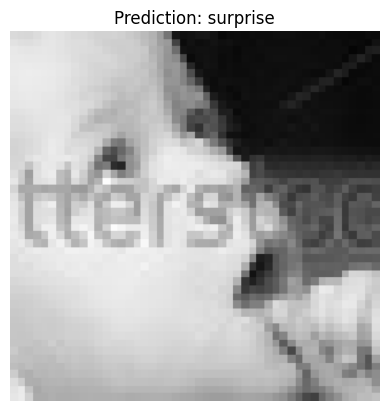

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Step 1: Image path (dataset)
img_path = "/content/dataset/images/validation/surprise/22025.jpg"

# Class names
class_names = ['angry','disgust','fear','happy','neutral','sad','surprise']

# Step 2: Load & preprocess image
img = tf.keras.utils.load_img(img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Step 3: Prediction
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Predicted Emotion:", predicted_class)

# Step 4: Show image
plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + predicted_class)
plt.show()

###The model correctly predicted the emotion ‘surprise’ for the given image. The facial features such as widened eyes and open mouth are characteristic of a surprised expression, and the model successfully captured these features during prediction.

###Neutral : Facial emotion recognition

In [ ]:
import os

print(os.listdir("/content/dataset/images/validation/neutral")[:5])

['31486.jpg', '32671.jpg', '8687.jpg', '13653.jpg', '1685.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Emotion: neutral


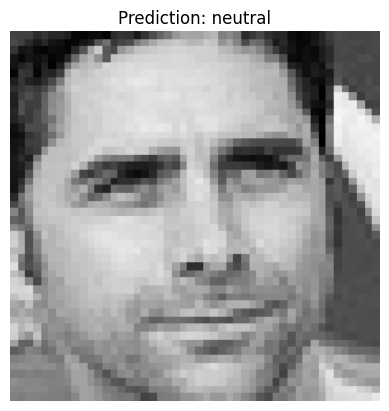

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Step 1: Image path (dataset)
img_path = "/content/dataset/images/validation/neutral/32671.jpg"

# Class names
class_names = ['angry','disgust','fear','happy','neutral','sad','surprise']

# Step 2: Load & preprocess image
img = tf.keras.utils.load_img(img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Step 3: Prediction
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Predicted Emotion:", predicted_class)

# Step 4: Show image
plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + predicted_class)
plt.show()

###The model correctly predicted the emotion ‘neutral’ for the given image. Since the facial expression does not exhibit strong emotional features such as smiling or frowning, it is classified as neutral. This demonstrates the model’s ability to distinguish between expressive and non-expressive faces.

###Sad: Facial emotion recognition

In [ ]:
import os

print(os.listdir("/content/dataset/images/validation/sad")[:5])

['359.jpg', '30326.jpg', '1891.jpg', '26378.jpg', '33686.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Emotion: sad


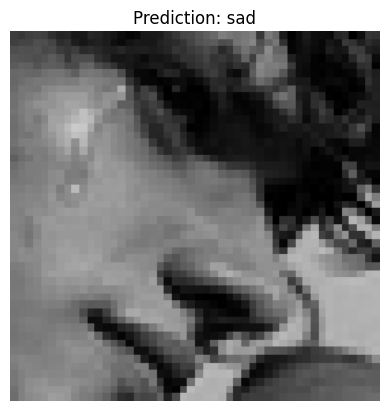

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Step 1: Image path (dataset)
img_path = "/content/dataset/images/validation/sad/30326.jpg"

# Class names
class_names = ['angry','disgust','fear','happy','neutral','sad','surprise']

# Step 2: Load & preprocess image
img = tf.keras.utils.load_img(img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Step 3: Prediction
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Predicted Emotion:", predicted_class)

# Step 4: Show image
plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + predicted_class)
plt.show()

###The model correctly predicted the emotion ‘sad’ for the given image. The facial features such as a lowered expression and lack of positive cues were successfully identified by the model, demonstrating its ability to recognize subtle emotional states.

##Angry: Facial emotion recognition

In [ ]:
import os

print(os.listdir("/content/dataset/images/validation/angry")[:5])

['2709.jpg', '33890.jpg', '25886.jpg', '7886.jpg', '22183.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Emotion: angry


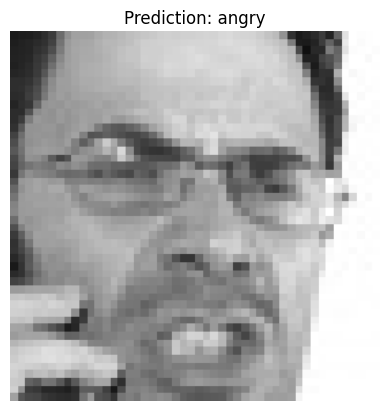

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Step 1: Image path (dataset)
img_path = "/content/dataset/images/validation/angry/25886.jpg"

# Class names
class_names = ['angry','disgust','fear','happy','neutral','sad','surprise']

# Step 2: Load & preprocess image
img = tf.keras.utils.load_img(img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Step 3: Prediction
pred = model.predict(img_array)
predicted_class = class_names[np.argmax(pred)]

print("Predicted Emotion:", predicted_class)

# Step 4: Show image
plt.imshow(img)
plt.axis('off')
plt.title("Prediction: " + predicted_class)
plt.show()

###The model correctly predicted the emotion ‘angry’ for the given image. The facial features such as furrowed eyebrows, intense gaze, and tightened facial muscles are characteristic of anger, and the model successfully identified these features.

##:The model was optimized for efficiency and speed by using a lightweight architecture (MobileNetV2), which enables faster predictions. The system produces results with low latency, making it suitable for real-time applications, while maintaining a reasonable level of accuracy.

###Save model:

In [ ]:
model.save("emotion_model.keras")

##Conclusion:  
###The facial emotion recognition system was successfully developed using a Convolutional Neural Network with transfer learning based on MobileNetV2. The model was trained on a dataset containing seven emotion classes: angry, disgust, fear, happy, neutral, sad, and surprise. Data augmentation techniques were applied to improve generalization. After training and fine-tuning, the model achieved an accuracy of approximately 51% on the validation dataset.

The model performed well in recognizing clear and distinct emotions such as happy, surprise, neutral, sad, angry while it showed lower performance for emotions like fear and disgust due to similarities in facial expressions and possible class imbalance. Evaluation using confusion matrix and classification metrics highlighted both strengths and limitations of the system.

A simple user interface was implemented to allow image-based emotion prediction, demonstrating the practical applicability of the model. Overall, the system provides a functional and effective solution for facial emotion recognition and can be further improved with more data and advanced techniques for real-world applications.

##I built, trained, tested, and demonstrated a working emotion recognition system.